# Imports

In [ ]:
%%capture
!cmd /c dependencies.bat

In [71]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import random
from collections import defaultdict
import pickle

In [72]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D

In [73]:
random.seed(42)

# Auxiliar functions
## Dataset

In [74]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [75]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']
['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']


In [76]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path)

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename        label
0  Session_001  Session_001/capture_0000.png  colocarPila
1  Session_001  Session_001/capture_0001.png  colocarPila
2  Session_001  Session_001/capture_0002.png  colocarPila
3  Session_001  Session_001/capture_0003.png  colocarPila
4  Session_001  Session_001/capture_0004.png  colocarPila


In [77]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004
../capturas/capturas_256x256/capturasVR\Session_005
../capturas/capturas_256x256/capturasVR\Session_006
../capturas/capturas_256x256/capturasVR\Session_007


In [78]:
def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(256, 256))  
    img = image.img_to_array(img)  # (256, 256, 3)
    img = img / 255.0  
    return img

## Plotting function

In [ ]:
def plot_from_history(history, epochs):

    # Manejar tanto objeto history como dict directamente
    if hasattr(history, 'history'):
        hist = history.history
    else:
        hist = history

    acc = hist['accuracy']
    val_acc = hist['val_accuracy']

    loss = hist['loss']
    val_loss = hist['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

## Save and load history

In [79]:
def save_history(history, nombre_archivo):
    with open(nombre_archivo, "wb") as f:
        pickle.dump(history.history, f)

def load_history(nombre_archivo):
    if os.path.exists(nombre_archivo):
        with open(nombre_archivo, "rb") as f:
            loaded_history = pickle.load(f)
        print(f"Historial cargado desde {nombre_archivo}.")
        return loaded_history
    else:
        print(f"No se encontró el archivo {nombre_archivo}.")
        return None

# Time Series
Given a window of n images, predict n+1

In [14]:
seq_by_session = {}

for entry in os.listdir(path_capturasVR):
    entry_path = os.path.join(path_capturasVR, entry)
    # comprobar que es un directorio y que empieza por "Session_"
    if os.path.isdir(entry_path) and entry.startswith("Session_"):
        # filtrar imágenes .png y ordenar
        image_files = [f for f in os.listdir(entry_path) if f.endswith(".png")]
        image_paths = [os.path.join(entry_path, f) for f in sorted(image_files)]
        seq_by_session[entry] = image_paths

In [15]:
# Crear X_train e Y_train y X_test e Y_test
sessions = list(seq_by_session.keys())

train_ratio = 0.8
n_train = int(len(sessions) * train_ratio)

random.shuffle(sessions)
sessions_train = sessions[:n_train]
sessions_test = sessions[n_train:]

In [16]:
print(sessions_train)
print(sessions_test)

['Session_002', 'Session_004', 'Session_005', 'Session_003', 'Session_007']
['Session_001', 'Session_006']


In [17]:
seq_train = {k: seq_by_session[k] for k in sessions_train}
seq_test  = {k: seq_by_session[k] for k in sessions_test}

In [18]:
def sequence_imgs(session_path, n_timesteps): 
    X, Y = [], []

    if len(session_path) <= n_timesteps:
        return X, Y

    for i in range(len(session_path) - n_timesteps):
        input_paths = session_path[i:i+n_timesteps]         # 5 imágenes
        target_path = session_path[i+n_timesteps]           # 1 imagen siguiente

        x_batch = [load_and_preprocess(p) for p in input_paths]
        y_img   = load_and_preprocess(target_path)

        X.append(np.array(x_batch))
        Y.append(y_img)

    return np.array(X), np.array(Y)

In [19]:
window_size = 5

def sequence_imgs_all_sessions(seq_dict, n_timesteps):
    X_total, Y_total = [], []
    for session, paths in seq_dict.items():
        X_sess, Y_sess = sequence_imgs(paths, n_timesteps)
        X_total.extend(X_sess)
        Y_total.extend(Y_sess)
        
    return np.array(X_total), np.array(Y_total)

In [20]:
X_train, Y_train = sequence_imgs_all_sessions(seq_train, window_size)
X_test,  Y_test  = sequence_imgs_all_sessions(seq_test,  window_size)

In [21]:
model_ts = Sequential([
   
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(5, 256, 256, 3)
    ),
    BatchNormalization(),
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),
    Conv2D(
        filters=3,
        kernel_size=(3, 3),
        activation="sigmoid",
        padding="same"
    )
])

c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:

model_ts.summary()

epochs_ts = 10
# Training
history_ts = model_ts.fit(
    X_train, Y_train,
    epochs=epochs_ts,
    batch_size=4,
    verbose=1, 
    validation_split=0.2
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 256, 256,    │        40,448 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 256, 256,    │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 256, 256, 32)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,299 (450.39 KB)

 Trainable params: 115,235 (450.14 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 472s 2s/step - accuracy: 0.9522 - loss: 0.0083 - mae: 0.0471 - val_accuracy: 0.9701 - val_loss: 0.0402 - val_mae: 0.1622
Epoch 2/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.9580 - loss: 0.0066 - mae: 0.0373 - val_accuracy: 0.8625 - val_loss: 0.0115 - val_mae: 0.0787
Epoch 3/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.9625 - loss: 0.0063 - mae: 0.0342 - val_accuracy: 0.8040 - val_loss: 0.0140 - val_mae: 0.0951
Epoch 4/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.9671 - loss: 0.0062 - mae: 0.0335 - val_accuracy: 0.8550 - val_loss: 0.0078 - val_mae: 0.0483
Epoch 5/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.9653 - loss: 0.0062 - mae: 0.0333 - val_accuracy: 0.8656 - val_loss: 0.0108 - val_mae: 0.0770
Epoch 6/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.9675 - loss: 0.0061 - mae: 0.0321 - val_accuracy: 0.8722 - val_loss: 0.0071 - val_mae: 0.0409
Epoch 7/10
292/292 ━━━━━━━━━━━━━━━

In [ ]:
model_ts.save("modelo_prediccion_imagenes.keras")
save_history(history_ts, "history_ts.pkl")

In [25]:
model_ts = load_model("modelo_prediccion_imagenes.keras")
history_ts = load_history("history_ts.pkl")

Historial cargado desde history_ts.pkl.


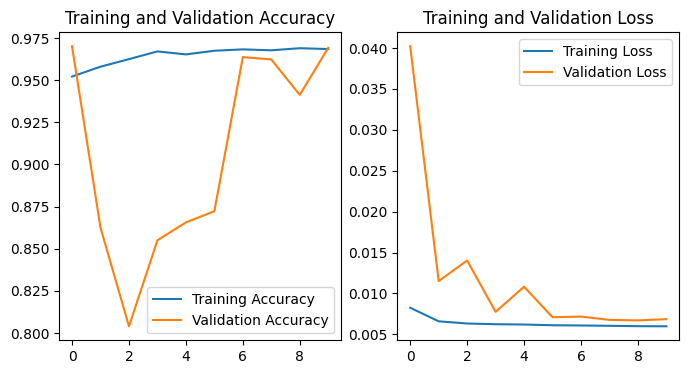

In [26]:
plot_from_history(history_ts, epochs = epochs_ts)

Todas las sesiones y sus sub procesos tienen casi el mismo número de imágenes. Probar a introducir sesiones más largas.  
Accuracy puede que no sirva porque la mayoria de la imagen es fondo

In [27]:
def predict_next_image(model, session, inicio, fin, n_timesteps):

    paths = session[inicio:fin+1]         # imagenes de indice inicio a fin
    if len(paths) < n_timesteps:
        print("Warning: la ventana es menor que n_timesteps")
        return None

    # Asegurar que la ventana tiene exactamente n_timesteps
    last_n = paths[-n_timesteps:]
    last_n_imgs = [load_and_preprocess(p) for p in last_n]
    X = np.array([np.array(last_n_imgs)])  # (1, n_timesteps, 256, 256, 3)

    pred = model.predict(X)                # (1, 256, 256, 3)
    return pred[0]

In [28]:
ind = 0
test_session_name = sessions_test[ind]                   

test_session_paths = seq_by_session[test_session_name]      
ini = 0
fin = 100

y_pred = predict_next_image(model_ts, test_session_paths, ini, fin, window_size)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


Forma de y_pred: (256, 256, 3)


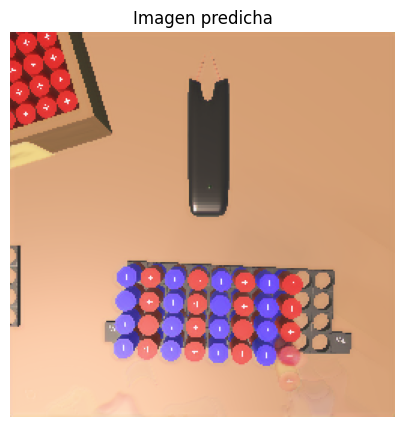

In [29]:
print("Forma de y_pred:", y_pred.shape)  # comprueba que es (256, 256, 3)

plt.figure(figsize=(5, 5))
plt.imshow(y_pred)
plt.title("Imagen predicha")
plt.axis("off")
plt.show()

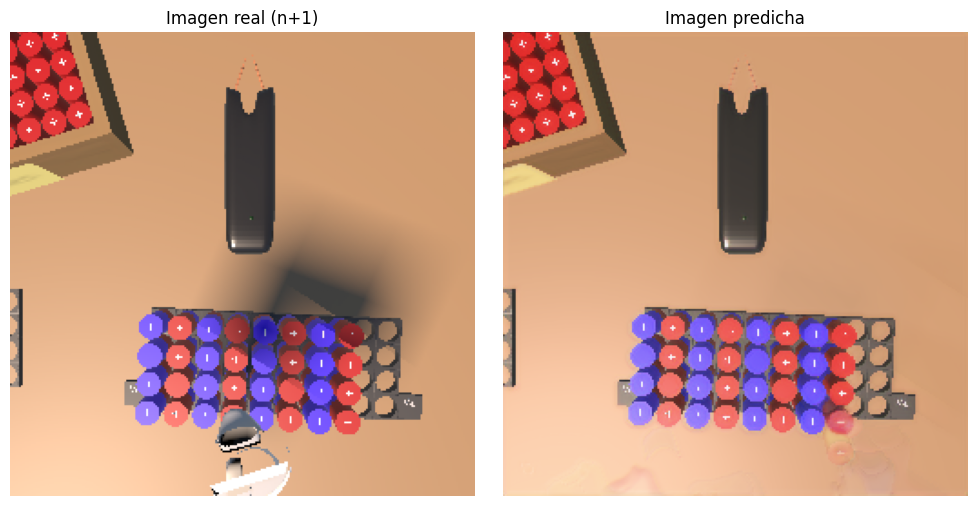

In [30]:
# Imagen real (la que el modelo debería predecir)
img_real = load_and_preprocess(test_session_paths[fin + 1])  # (256, 256, 3)

# Imagen predicha
img_pred = y_pred   # (256, 256, 3)

# Mostrar original y predicción lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img_real)
ax1.set_title("Imagen real (n+1)")
ax1.axis("off")

ax2.imshow(img_pred)
ax2.set_title("Imagen predicha")
ax2.axis("off")

plt.tight_layout()
plt.show()

In [33]:
def psnr_score(y_true, y_pred, max_val=1.0):
    mse = np.mean((y_true - y_pred) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10(max_val**2 / mse)

# Mide el ratio señal‑ruido entre ambas imágenes.
# Un PSNR alto indica una imagen muy parecida a la original.
score = psnr_score(img_real, img_pred, max_val=1.0)
print(f"PSNR: {score:.2f} dB")

mse = np.mean((img_real - img_pred) ** 2)
mae = np.mean(np.abs(img_real - img_pred))

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

PSNR: 20.83 dB
MSE: 0.008254
MAE: 0.040229


Total de imágenes en la secuencia: 102
Última imagen (n+1) ruta: ../capturas/capturas_256x256/capturasVR\Session_001\capture_0101.png


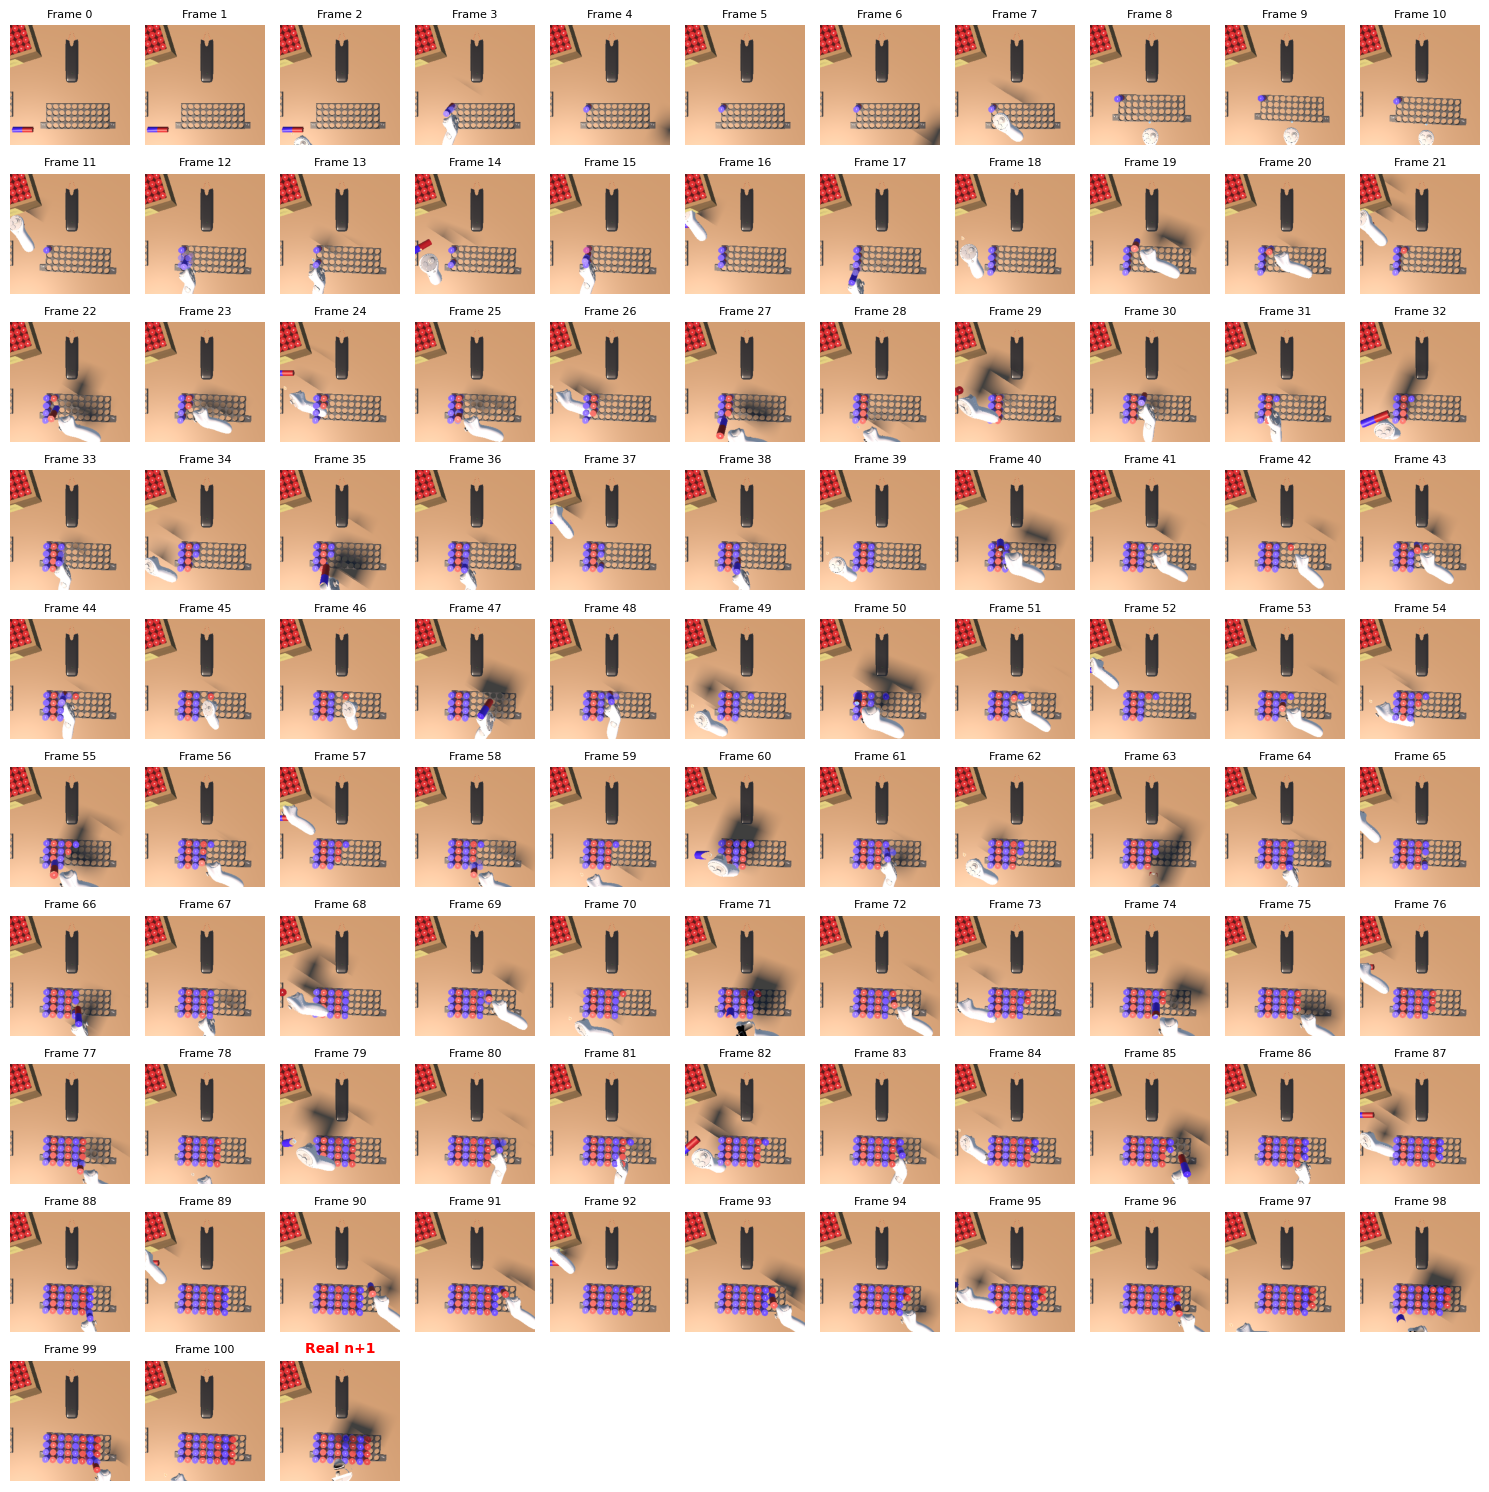

In [34]:
# Mostrar secuencia completa desde ini hasta fin + 1
sequence_paths = test_session_paths[ini:fin+2]  # ini a fin+1 inclusive

print(f"Total de imágenes en la secuencia: {len(sequence_paths)}")
print(f"Última imagen (n+1) ruta: {sequence_paths[-1] if len(sequence_paths) > 0 else 'No hay'}")

fig, axes = plt.subplots(10, 11, figsize=(15, 15))

# Aplanar los axes para iterar fácilmente
axes_flat = axes.flatten()

for idx, ax in enumerate(axes_flat):
    if idx < len(sequence_paths):
        img_path = sequence_paths[idx]
        img = load_and_preprocess(img_path)
        ax.imshow(img)
        
        is_last = (idx == len(sequence_paths) - 1)
        
        if is_last:
            ax.set_title("Real n+1", fontsize=10, color='red', weight='bold')
            # Agregar borde de color rojo a la imagen real
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
                spine.set_visible(True)
        else:
            ax.set_title(f"Frame {ini+idx}", fontsize=8)
    
    ax.axis("off")

plt.tight_layout()
plt.show()

# Image Classification

In [80]:
# Filtrar filas válidas (si hay imágenes faltantes)
df_valid = df[df['full_path'].apply(os.path.exists)].copy()

# Cargar imágenes y etiquetas
images = []
labels = []
image_names = []

for _, row in df_valid.iterrows():
    img_path = row['full_path']
    label = row['label']

    session_dir = os.path.dirname(img_path)                 
    session_name = os.path.basename(os.path.normpath(session_dir))  

    file_name_without_ext = os.path.splitext(os.path.basename(img_path))[0]

    relative_id = f"{session_name}\\{file_name_without_ext}"

    image_names.append(relative_id)

    # Cargar y preprocesar imagen
    img = load_and_preprocess(img_path)  # Usa la función existente
    images.append(img)
    labels.append(label)

# Convertir a arrays de NumPy
images = np.array(images)  # Forma: (num_samples, 256, 256, 3)
labels = np.array(labels)  # Forma: (num_samples,)
image_names = np.array(image_names)

print(f"Total de imágenes cargadas: {len(images)}")
print(f"Forma de images: {images.shape}")
print(f"Forma de labels: {labels.shape}")

# Dividir en train y test (80% train, 20% test)
train_images, test_images, train_labels, test_labels, train_names, test_names = \
    train_test_split(
        images, labels, image_names,
        test_size=0.2,
        random_state=42,
        stratify=labels
    )

print(f"Train images: {train_images.shape}, Train labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}, Test labels: {test_labels.shape}")

Total de imágenes cargadas: 2108
Forma de images: (2108, 256, 256, 3)
Forma de labels: (2108,)
Train images: (1686, 256, 256, 3), Train labels: (1686,)
Test images: (422, 256, 256, 3), Test labels: (422,)


In [81]:
mapa = {
    "colocarPila": 0,
    "colocarSoporteSup": 1,
    "colocarNiquel": 2,
    "soldar": 3
}

train_labels_encoded = np.array([mapa[x] for x in train_labels])
test_labels_encoded = np.array([mapa[x] for x in test_labels])

In [15]:
def show_image_and_label(images, labels, image_names, num_images=20):
  
    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"{name}\n{labels[i]}"
        
        plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
show_image_and_label(
    images        = train_images,       # (N, 256, 256, 3)
    labels        = train_labels,
    image_names   = train_names,        # lista/array de nombres de imágenes         
    num_images    = len(train_images)  #Cantidad de imágenes a mostrar
)

In [82]:
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

def training_pipeline(model, epochs = 10, validation_split = 0.2, lr=0.001):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',   factor=0.5,  patience=7,verbose=1, min_lr=4e-10
    )

    model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])
    
    history = model.fit(train_images, train_labels_encoded,epochs=epochs,batch_size = 32,validation_split=validation_split,callbacks = [lr_callback])

    train_loss, train_acc = model.evaluate(train_images,  train_labels_encoded, verbose=2)
    test_loss, test_acc = model.evaluate(test_images,  test_labels_encoded, verbose=2)
    
    return test_acc, train_acc, history

In [ ]:
model_class = Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Bloque 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Bloque 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Bloque 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # En lugar de Flatten(), usa GlobalAveragePooling2D()
    layers.GlobalAveragePooling2D(),                    
    layers.Dense(128, activation='relu'),               
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')                # 5 clases
])
epochs_class = 30
test_acc_class, train_acc_class, history_class = training_pipeline(model_class, epochs = epochs_class)
print(f"Test accuracy: {test_acc_class}\nTrain accuracy: {train_acc_class}")

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.6929 - loss: 0.9292 - val_accuracy: 0.4527 - val_loss: 1.6595 - learning_rate: 0.0010
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8872 - loss: 0.3925 - val_accuracy: 0.4527 - val_loss: 1.4150 - learning_rate: 0.0010
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8999 - loss: 0.3193 - val_accuracy: 0.4527 - val_loss: 2.4963 - learning_rate: 0.0010
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9080 - loss: 0.2933 - val_accuracy: 0.4527 - val_loss: 2.3079 - learning_rate: 0.0010
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9206 - loss: 0.2495 - val_accuracy: 0.4527 - val_loss: 4.7045 - learning_rate: 0.0010
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9214 - loss: 0.2796 - val_accuracy: 0.4527 - val_loss: 9.2641 - learning_rate: 0.0010
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9288 - loss: 0.2233 - val_accuracy: 

In [84]:
model_class.save("modelo_clasificacion_imagenes.keras")
save_history(history_class, "history_class.pkl")

In [ ]:
model_class = load_model("modelo_clasificacion_imagenes.keras")
history_class = load_history("history_class.pkl")

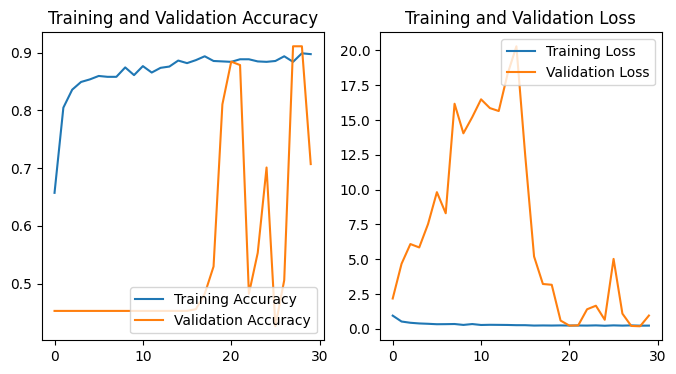

In [40]:
plot_from_history(history_class, epochs = epochs_class)

In [ ]:
y_pred_class = model_class.predict(test_images)
y_pred_labels = [encoder(pred) for pred in y_pred_class]

In [ ]:
def show_predictions_and_accuracy(y_pred, y_pred_labels, test_images, y_true_labels, image_names, num_images=20):
  
    y_true = np.array(y_true_labels)
    y_pred = np.array(y_pred_labels)

    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(test_images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = test_images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"Real: {y_true[i]}\nPred: {y_pred[i]}\n{name}"
        if y_true[i] == y_pred[i]:
            plt.title(title, color="blue", fontsize=8)
        else:
            plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Calcular accuracy total
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

In [ ]:
show_predictions_and_accuracy(
    y_pred        = y_pred_class,       
    y_pred_labels = y_pred_labels,
    test_images   = test_images,       # (N, 256, 256, 3)
    y_true_labels = test_labels,
    image_names   = test_names,        # lista/array de nombres de imágenes
    num_images    = len(test_images)  #Cantidad de imágenes a mostrar
)